**Problem 1: Extending the lady tasting tea**


Let's extend the Lady Tasting Tea experiment as follows. The original experiment has 8 cups: 4 tea-first and 4 milk-first. Suppose we prepare 12 cups: 8 tea-first and 4 milk-first. A participant claims they can tell which was poured first.

Simulate this experiment using numpy by randomly shuffling the cups many times and calculating the probability of the participant correctly identifying all cups by chance. Compare your result with the original 8-cup experiment.

In your notebook, explain your simulation process clearly, report and interpret the estimated probability, and discuss whether, based on this probability, you would consider extending or relaxing the p-value threshold compared to the original design.

Simulation taste test using NumPy to identify which 4 cups out of 12 cups had milk added first

-   Original test: 8 cups (4 tea-first, 4 milk-first)
-   Extended test: 12 cups ( 8 tea-first, 4 milk-first)

Goal: Estimate the probability that someone could correctly identify all milk-first cups by random guessing. 


*Null Hypothesis:*

The person testing the tea has no special ability to tell the difference between the cups of tea with milk in first and is selecting the four cups from the twelve randomly.

*Alternative Hypothesis:*

The person has some ability to identify the four cups with milk poured first and result is better than random chance. 

### Simulation process:

In [ ]:
# Number of cups of tea in total. 
total_cups_of_tea = 12
# Number of cups of tea with milk in first.
cups_with_milk_first = 4
# Number of cups of tea with tea in first.
cups_with_tea_first = 8

In [7]:
import numpy as np

# Setup: number of cups
total_cups = 12
milk_first = 4
tea_first = 8

def simulate_guess(tea, milk, simulations=100000):
    cups = np.array([1]*milk + [0]*tea)  # 1 = milk first, 0 = tea first
    total = tea + milk
    success = 0

    for _ in range(simulations):
        np.random.shuffle(cups)
        guess = np.random.choice(total, milk, replace=False)
        if np.all(cups[guess] == 1):
            success += 1

    return success / simulations

# Run simulations
prob_12 = simulate_guess(tea_first, milk_first)
prob_8 = simulate_guess(4, 4)

print(f"Probability (12 cups): {prob_12:.5f}")
print(f"Probability (8 cups): {prob_8:.5f}")


Probability (12 cups): 0.00206
Probability (8 cups): 0.01391


-   NumPy array tp represent cups: 1 --> milk first 0 --> tea first 
-   simulation ran 100,000 times using function. 
-   In each simulation it shuffles the order of the cups and randomly selects 4 cups as the ladys guess for the milk first cups. 
-  for all 4 guessed correctly (all 1's) --> success

-   



***

**Problem 2: Normal Distribution:**

Generate 100,000 samples of size 10 from the standard normal distribution. For each sample, compute the standard deviation with ddof=1 (sample SD) and with ddof=0 (population SD). Plot histograms of both sets of values on the same axes with transparency. Describe the differences you see. Explain how you expect these differences to change if the sample size is increased.

https://numpy.org/doc/2.1/reference/random/generated/numpy.random.normal.html

In [1]:
import numpy as np
import matplotlib.pyplot as plt

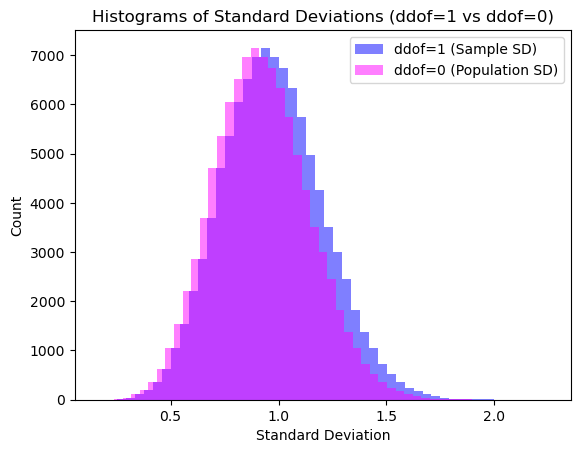

In [5]:
number_samples = 100000 
sample_size = 10 

samples = np.random.normal(loc=0, scale=1, size=(number_samples, sample_size))



std_ddof1 = np.std(samples, axis=1, ddof=1)  # Sample standard deviation 
std_ddof0 = np.std(samples, axis=1, ddof=0)  # Population standard deviation

# Plot histograms
plt.hist(std_ddof1, bins=50, alpha=0.5, label='ddof=1 (Sample SD)', color='blue')
plt.hist(std_ddof0, bins=50, alpha=0.5, label='ddof=0 (Population SD)', color='magenta')
plt.xlabel('Standard Deviation')
plt.ylabel('Count')
plt.title('Histograms of Standard Deviations (ddof=1 vs ddof=0)')
plt.legend()
plt.show()

-   ddof=1: is more on right-larger SD
-   ddof=0: more left-smaller SD
-   both are normally distributed
-   